In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

# Tunable Custom Circuit Analysis

This notebook follows the pedagogical flow of scqubits `demo_customcircuit.ipynb`, but applies it to the grounded Yan-style tunable-coupler circuit currently supported in `ScQubitsMimic.jl`.

The physical system is not the scqubits `0-π` circuit. Instead, we study a three-loop grounded circuit with left-qubit, coupler, and right-qubit SQUID loops. Supported symbolic and direct-diagonalization APIs are arranged in the same order as the scqubits tutorial, while unsupported sections are left in place as explicit notes.


## Circuit Information and Define Circuit

The YAML description below builds a grounded three-node circuit. The three superconducting loops will later be identified with `Φ1` (left qubit), `Φ2` (middle coupler), and `Φ3` (right qubit).


In [2]:
tcap_coupled_tmon = """
branches:
  - [JJ, 0, 1, EJ=4.5, EC=0.1]
  - [JJ, 1, 0, EJ=10.5, EC=0.1]
  - [C, 1, 0, EC=0.2]
  - [C, 1, 2, EC=5.0]
  - [JJ, 0, 2, EJ=30.0, EC=0.1]
  - [JJ, 2, 0, EJ=20.0, EC=0.1]
  - [C, 2, 0, EC=0.1]
  - [C, 2, 3, EC=5.0]
  - [JJ, 0, 3, EJ=4.6, EC=0.1]
  - [JJ, 3, 0, EJ=10.0, EC=0.1]
  - [C, 3, 0, EC=0.2]
"""

circ1 = Circuit(tcap_coupled_tmon; ncut=6)


Circuit(SymbolicCircuit(CircuitGraph(Branch[Branch(JJ, 0→1, EJ=4.5, EC=0.1), Branch(JJ, 1→0, EJ=10.5, EC=0.1), Branch(C, 1→0, EC=0.2), Branch(C, 1→2, EC=5.0), Branch(JJ, 0→2, EJ=30.0, EC=0.1), Branch(JJ, 2→0, EJ=20.0, EC=0.1), Branch(C, 2→0, EC=0.1), Branch(C, 2→3, EC=5.0), Branch(JJ, 0→3, EJ=4.6, EC=0.1), Branch(JJ, 3→0, EJ=10.0, EC=0.1), Branch(C, 3→0, EC=0.2)], 3, true), [3, 4, 8], [1, 2, 5, 6, 7, 9, 10, 11], [[(1, 1), (3, 1)], [(2, 1), (3, -1)], [(5, 1), (3, 1), (4, -1)], [(6, 1), (4, 1), (3, -1)], [(7, 1), (4, 1), (3, -1)], [(9, 1), (3, 1), (4, -1), (8, -1)], [(10, 1), (8, 1), (4, 1), (3, -1)], [(11, 1), (8, 1), (4, 1), (3, -1)]], [2, 6, 10], [[(2, 1), (1, 1)], [(6, 1), (5, 1)], [(10, 1), (9, 1)]], Symbolics.Num[φ₁, φ₂, φ₃], Symbolics.Num[φ̇₁, φ̇₂, φ̇₃], Symbolics.Num[3.15 -0.025 0; -0.025 3.8 -0.025; 0 -0.025 3.15], Symbolics.Num[0 0 0; 0 0 0; 0 0 0], -10.0cos(Φ3 - φ₃) - 4.5cos(φ₁) - 4.6cos(φ₃) - 30.0cos(φ₂) - 10.5cos(Φ1 - φ₁) - 20.0cos(Φ2 - φ₂) + 0.6349537900451738(n₁^2) + 0.008

## Lagrangian and Variable Transformation

We first inspect the symbolic Lagrangian in the node basis, then compare it with the transformed-variable basis used internally for classification and quantization.


**Lagrangian in terms of node variables**


In [3]:
sym_lagrangian(circ1; vars_type=:node)


10.0cos(Φ3 - φ₃) + 4.5cos(φ₁) + 4.6cos(φ₃) + 30.0cos(φ₂) + 10.5cos(Φ1 - φ₁) + 20.0cos(Φ2 - φ₂) + (3.15(φ̇₁^2 + φ̇₃^2) - 0.05φ̇₁*φ̇₂ + 3.8(φ̇₂^2) - 0.05φ̇₂*φ̇₃) / 2

**Transformation between node variables and new variables**


In [4]:
variable_transformation(circ1)


([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0], VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]))

In [5]:
circ1.transformation_matrix


3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

**Types of the transformed variables**


In [6]:
circ1.var_categories


VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])

**Lagrangian in terms of new variables**


In [7]:
sym_lagrangian(circ1; vars_type=:new)


30.0cos(θ₂) + 4.6cos(θ₃) + 4.5cos(θ₁) + 20.0cos(Φ2 - θ₂) + 10.0cos(Φ3 - θ₃) + 10.5cos(Φ1 - θ₁) + (3.15(θ̇₁^2 + θ̇₃^2) - 0.05(θ̇₁ + θ̇₃)*θ̇₂ + 3.8(θ̇₂^2)) / 2

## Hamiltonian and Diagonalization

At the moment this grounded Yan-style circuit is classified as three periodic modes and no extended modes, so each mode is quantized in the charge basis `|n⟩` with `n = -ncut:ncut`. For the main analysis object `circ1` we use `ncut = 6`, giving `2*ncut + 1 = 13` basis states per mode and a global direct-diagonalization Hilbert-space dimension of `13^3 = 2197`. The numerical engine does not introduce a subsystem hierarchy here; instead it constructs the full circuit Hamiltonian in that tensor-product charge basis and directly diagonalizes it to obtain the low-lying eigenspectrum. The coupler-flux sweep below repeats that same full direct diagonalization at each `Φ2` bias point.


**Symbolic Hamiltonian**


In [8]:
sym_hamiltonian_node(circ1)


-10.0cos(Φ3 - φ₃) - 4.5cos(φ₁) - 4.6cos(φ₃) - 30.0cos(φ₂) - 10.5cos(Φ1 - φ₁) - 20.0cos(Φ2 - φ₂) + 0.6349537900451738(n₁^2) + 0.00835509138381201n₁*n₂ + 6.631024907787311e-5n₁*n₃ + 0.5263707571801567(n₂^2) + 0.008355091383812014n₂*n₃ + 0.6349537900451739(n₃^2)

In [9]:
sym_hamiltonian(circ1)


-30.0cos(θ₂) - 4.6cos(θ₃) - 4.5cos(θ₁) - 20.0cos(Φ2 - θ₂) - 10.0cos(Φ3 - θ₃) - 10.5cos(Φ1 - θ₁) + 0.6349537900451738(nθ₁^2) + 0.00835509138381201nθ₁*nθ₂ + 6.631024907787311e-5nθ₁*nθ₃ + 0.5263707571801567(nθ₂^2) + 0.008355091383812014nθ₂*nθ₃ + 0.6349537900451739(nθ₃^2)

**Offset-charge variables and transformation**

`offset_charges(circ1)` lists the periodic transformed-mode offset-charge symbols used by the numerical charging Hamiltonian. `offset_charge_transformation(circ1)` now exposes the scqubits-style linear mapping from node-charge placeholders `q_n1`, `q_n2`, `q_n3` to those `ng` variables. For this grounded example the transformation matrix is the identity, so the mapping is trivial, but the same helper follows the actual transformed-mode indexing rule `inv(Tᵀ)[mode, :]` in general.


In [10]:
offset_charges(circ1)


3-element Vector{Symbolics.Num}:
 ng1
 ng2
 ng3

In [11]:
offset_charge_transformation(circ1)


3-element Vector{Any}:
 ng1 ~ q_n1
 ng2 ~ q_n2
 ng3 ~ q_n3

3-element Vector{Any}:
 ng1 ~ q_n1
 ng2 ~ q_n2
 ng3 ~ q_n3

In [12]:
circ_ng = Circuit(tcap_coupled_tmon; ncut=6)
set_param!(circ_ng, :ng2, 0.1)
evals_ng = eigenvals(circ_ng; evals_count=4)

println("Representative periodic-mode offset charge: ng2 = ", get_param(circ_ng, :ng2))
println("ω01 at ng2 = 0.1: ", evals_ng[2] - evals_ng[1], " GHz")


Representative periodic-mode offset charge: ng2 = 0.1
ω01 at ng2 = 0.1: 4.140823800364089 GHz


**Cutoff properties**

The repo now exposes scqubits-style cutoff properties on `Circuit`. The available names depend on `var_categories`: periodic modes use `cutoff_n_i`, while extended modes use `cutoff_ext_i`. Since `circ1` has three periodic modes and no extended modes, only `cutoff_n_1`, `cutoff_n_2`, and `cutoff_n_3` appear below.


In [13]:
circ_cut = Circuit(tcap_coupled_tmon; ncut=6)

println("cutoff_names = ", circ_cut.cutoff_names)
println("Initial cutoff_n_2 = ", circ_cut.cutoff_n_2)
println("Initial Hilbert dimension = ", hilbertdim(circ_cut))

circ_cut.cutoff_n_2 = 4

println("Updated cutoff_n_2 = ", circ_cut.cutoff_n_2)
println("Internal stored dimension for mode 2 = ", circ_cut.cutoffs[2])
println("Updated Hilbert dimension = ", hilbertdim(circ_cut))


cutoff_names = [:cutoff_n_1, :cutoff_n_2, :cutoff_n_3]
Initial cutoff_n_2 = 6
Initial Hilbert dimension = 2197
Updated cutoff_n_2 = 4
Internal stored dimension for mode 2 = 9
Updated Hilbert dimension = 1521


**Current scope in this section**

Per-mode cutoff editing is now available for top-level `Circuit`. This notebook still keeps a single global `ncut=6` for the main analysis object `circ1`, and uses `circ_cut` above only to demonstrate how the per-mode cutoff API changes the truncated Hilbert space.


**Direct-diagonalization sanity check**

The short loop below re-instantiates the same YAML circuit specification at `ncut in (4, 5, 6)` and reports the resulting mode dimensions, total Hilbert-space dimension, and the first two transition frequencies. The goal is not to reuse the same `Circuit` object, but to compare how the global charge-basis truncation changes the low-lying spectrum for the same physical circuit description.


In [14]:
for ncut in (4, 5, 6)
    circ_check = Circuit(tcap_coupled_tmon; ncut=ncut)
    mode_order = vcat(circ_check.var_categories.periodic, circ_check.var_categories.extended)
    mode_dims = [circ_check.cutoffs[mode] for mode in mode_order]
    evals_check = eigenvals(circ_check; evals_count=4)

    println((
        ncut=ncut,
        var_categories=circ_check.var_categories,
        mode_dims=mode_dims,
        total_dim=prod(mode_dims),
        ω01=evals_check[2] - evals_check[1],
        ω12=evals_check[3] - evals_check[2],
    ))
end


(ncut = 4, var_categories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]), mode_dims = [9, 9, 9], total_dim = 729, ω01 = 4.21851763093926, ω12 = 0.06576319929308738)
(ncut = 5, var_categories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]), mode_dims = [11, 11, 11], total_dim = 1331, ω01 = 4.147321828877196, ω12 = 0.05957662382570561)
(ncut = 6, var_categories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[]), mode_dims = [13, 13, 13], total_dim = 2197, ω01 = 4.1408237055940305, ω12 = 0.058739370654876666)


In [15]:
evals0 = eigenvals(circ1; evals_count=4)
transitions0 = (
    ω01 = evals0[2] - evals0[1],
    ω12 = evals0[3] - evals0[2],
    ω23 = evals0[4] - evals0[3],
)

println("Eigenvalues: ", evals0)
println("Transitions: ", transitions0)


Eigenvalues: [-71.73377650684469, -67.59295280125066, -67.53421343059578, -64.44304261918275]
Transitions: (ω01 = 4.1408237055940305, ω12 = 0.058739370654876666, ω23 = 3.0911708114130363)


## Set External Fluxes

The scqubits tutorial next identifies the external-flux symbols and then sweeps one of them. For this Yan-style circuit, `sym_external_fluxes(circ1)` shows that `Φ1` closes the left-qubit loop, `Φ2` the middle coupler loop, and `Φ3` the right-qubit loop.


In [16]:
sym_external_fluxes(circ1)


Dict{Symbolics.Num, @NamedTuple{closure_branch::Int64, loop::Vector{Tuple{Int64, Int64}}}} with 3 entries:
  Φ3 => (closure_branch = 10, loop = [(10, 1), (9, 1)])
  Φ1 => (closure_branch = 2, loop = [(2, 1), (1, 1)])
  Φ2 => (closure_branch = 6, loop = [(6, 1), (5, 1)])

**Coupler-flux sweep**

We now fix `Φ1 = Φ3 = 0` and sweep only `Φ2`, which tunes the middle SQUID loop. In the present circuit convention the sweep variable is a phase bias in radians, so `Φ2 = π` corresponds to the frustration point of the coupler SQUID.


In [17]:
circ_flux = Circuit(tcap_coupled_tmon; ncut=6)
set_param!(circ_flux, "Φ1", 0.0)
set_param!(circ_flux, "Φ3", 0.0)

φ2_vals = collect(range(-π, π; length=101))
flux_sweep = get_spectrum_vs_paramvals(circ_flux, "Φ2", φ2_vals; evals_count=4)

relative_levels = flux_sweep.eigenvalues .- flux_sweep.eigenvalues[:, 1]
transitions = hcat(
    flux_sweep.eigenvalues[:, 2] .- flux_sweep.eigenvalues[:, 1],
    flux_sweep.eigenvalues[:, 3] .- flux_sweep.eigenvalues[:, 2],
    flux_sweep.eigenvalues[:, 4] .- flux_sweep.eigenvalues[:, 3],
)

println("Computed ", length(φ2_vals), " sweep points.")
println("First relative spectrum row: ", relative_levels[1, :])


Computed 101 sweep points.
First relative spectrum row: [0.0, 3.1067186212632976, 4.141112568758498, 4.199851493876725]


## Spectrum Plots


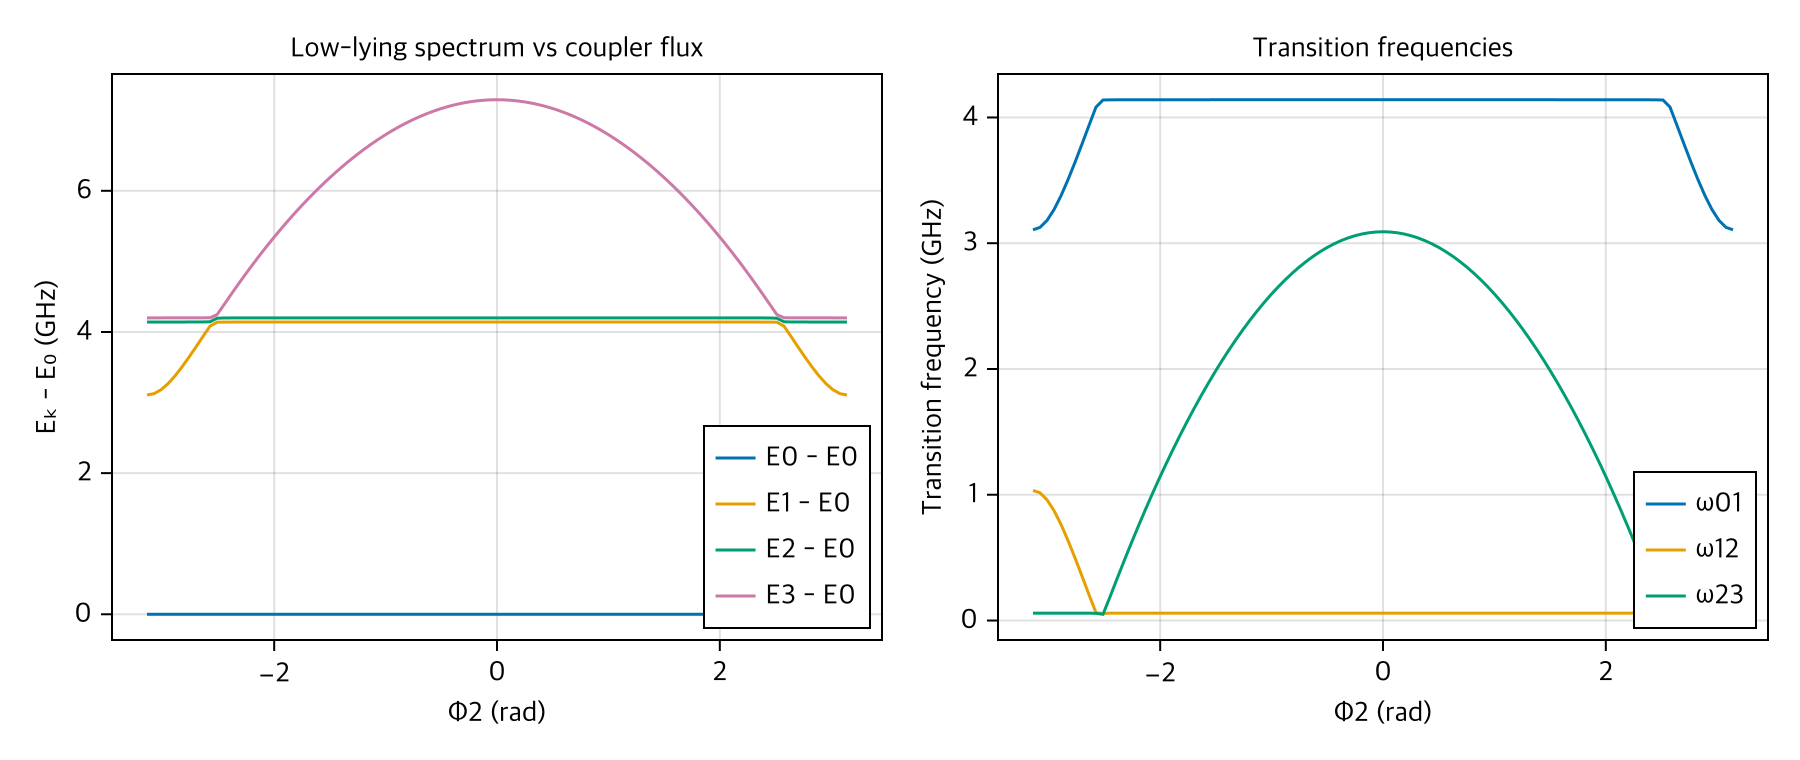

In [18]:
fig = Figure(size=(900, 380))

ax1 = Axis(fig[1, 1],
    xlabel="Φ2 (rad)",
    ylabel="Eₖ - E₀ (GHz)",
    title="Low-lying spectrum vs coupler flux")

for k in 1:size(relative_levels, 2)
    lines!(ax1, φ2_vals, relative_levels[:, k], label="E$(k-1) - E0")
end
axislegend(ax1, position=:rb)

ax2 = Axis(fig[1, 2],
    xlabel="Φ2 (rad)",
    ylabel="Transition frequency (GHz)",
    title="Transition frequencies")
lines!(ax2, φ2_vals, transitions[:, 1], label="ω01")
lines!(ax2, φ2_vals, transitions[:, 2], label="ω12")
lines!(ax2, φ2_vals, transitions[:, 3], label="ω23")
axislegend(ax2, position=:rb)

fig


## Hierarchical Diagonalization and Subsystem Interactions

The actual spectrum data in this notebook comes from the direct-diagonalization workflow above. In scqubits, the next section configures subsystem groupings and inspects subsystem Hamiltonians and interaction terms. The current repo does not yet expose the corresponding tutorial APIs:

- `configure(...)`
- `sym_hamiltonian(subsystem_index=...)`
- `sym_interaction(...)`


## Visualization Capabilities

The scqubits example also shows potential-energy cross-sections and circuit wavefunctions. Those are not yet available for `Circuit` in this repo:

- `plot_potential`
- `Circuit` wavefunction plotting
